In [2]:
# venv setup for fraud detection project
# ----------------------------------------
# python -m venv fraud_detection
# fraud_detection\Scripts\activate

# Install ipykernel to use the virtual environment in Jupyter Notebook as Kernel
# -------------------------------------------------------------------------------
# pip install ipykernel
# Register your venv as a kernel
# python -m ipykernel install --user --name=fraud_detection --display-name "Python (fraud_detection)"


In [3]:
# In Python, a single backslash \ is an escape character, so for example:
# "C:\Users\49152\anaconda3\Scripts\180\DAYS_COMMITED\20260122\ML_Proj"


# …Python interprets \U as the start of a Unicode escape, which will raise an error.

# ✅ How to fix it

# You have three options:

# 1. Use raw string (simplest)
# path = kagglehub.dataset_download(
#     "amanalisiddiqui/fraud-detection-dataset",
#     path=r"C:\Users\49152\anaconda3\Scripts\180\DAYS_COMMITED\20260122\ML_Proj"
# )


# The r before the string tells Python: “don’t interpret backslashes as escapes.”

# 2. Use forward slashes

# Windows supports / in paths:

# path = kagglehub.dataset_download(
#     "amanalisiddiqui/fraud-detection-dataset",
#     path="C:/Users/49152/anaconda3/Scripts/180/DAYS_COMMITED/20260122/ML_Proj"
# )

# 3. Escape backslashes
# path = kagglehub.dataset_download(
#     "amanalisiddiqui/fraud-detection-dataset",
#     path="C:\\Users\\49152\\anaconda3\\Scripts\\180\\DAYS_COMMITED\\20260122\\ML_Proj"
# )


# Every backslash is doubled so Python reads it literally.


In [ ]:
# fraud-detection-ml/
# │
# ├── data/
# │   └── fraud_data.csv               # Kaggle dataset (NOT pushed to GitHub)
# │
# ├── notebooks/
# │   └── 01_exploratory_data_analysis.ipynb
# │
# ├── src/
# │   ├── __init__.py
# │   ├── data_loader.py
# │   ├── preprocessing.py
# │   ├── feature_engineering.py
# │   ├── model.py
# │   ├── evaluation.py
# │
# ├── app/
# │   └── fraud_detection_app.py        # Streamlit app
# │
# ├── models/
# │   └── fraud_detection_pipeline.pkl
# │
# ├── requirements.txt
# ├── README.md
# ├── .gitignore
# └── main.py


In [4]:
import os
import kagglehub

path = kagglehub.dataset_download("amanalisiddiqui/fraud-detection-dataset")

print("Dataset downloaded to:", path)
print("Files in dataset folder:", os.listdir(path))


Dataset downloaded to: C:\Users\49152\.cache\kagglehub\datasets\amanalisiddiqui\fraud-detection-dataset\versions\1
Files in dataset folder: ['AIML Dataset.csv']


In [5]:
import pandas as pd
import os

dataset_file = os.path.join(
    r"C:\Users\49152\.cache\kagglehub\datasets\amanalisiddiqui\fraud-detection-dataset\versions\1",
    "AIML Dataset.csv"
)

df = pd.read_csv(dataset_file)
print(df.head())


   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # pip install --upgrade matplotlib seaborn


In [ ]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


In [ ]:
df = pd.read_csv("AIML Dataset.csv")


In [ ]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.columns  


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
# Target Distribution & Class Imbalance
df["isFraud"].value_counts()

# Fraud percentage (0.13%)


isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [13]:
df["isFlaggedFraud"].value_counts()


isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [14]:
df.isnull() # if there is any na values # cellwise True/False


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6362615,False,False,False,False,False,False,False,False,False,False,False
6362616,False,False,False,False,False,False,False,False,False,False,False
6362617,False,False,False,False,False,False,False,False,False,False,False
6362618,False,False,False,False,False,False,False,False,False,False,False


In [15]:
df.isnull().sum() # columnwise sum of na values


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [ ]:
# Missing Values & Shape
df.isnull().sum().sum() # total na values in the dataframe


0

In [17]:
df.shape


(6362620, 11)

In [18]:
df["isFraud"].value_counts() # number of fraud and non-fraud cases in the dataset
df["isFraud"].value_counts()[1] # number of fraud cases in the dataset
df["isFraud"].value_counts()[1] / df.shape[0] # proportion of fraud cases in the dataset
df["isFraud"].value_counts()[1] / df.shape[0] * 100  # percentage of fraud cases in the dataset
round( df["isFraud"].value_counts()[1] / df.shape[0] * 100 , 2)  # rounded percentage of fraud cases in the dataset


isFraud
0    6354407
1       8213
Name: count, dtype: int64

8213

0.001290820448180152

0.12908204481801522

0.13

<Axes: title={'center': 'Transaction Type Distribution'}, xlabel='type'>

Text(0.5, 0, 'Transaction Type')

Text(0, 0.5, 'Count')

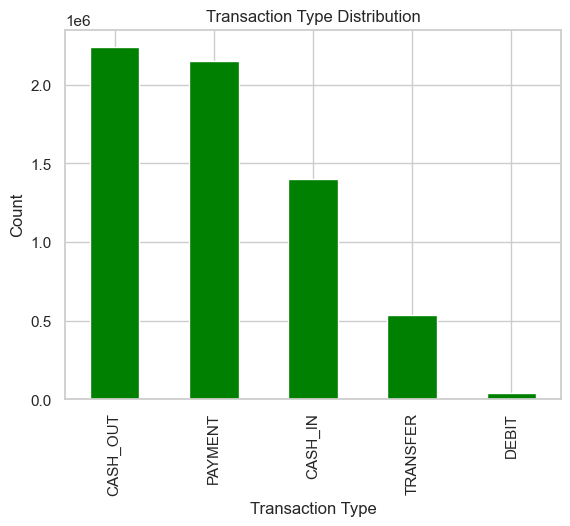

In [ ]:
# Transaction Type Analysis
df["type"].value_counts().plot(kind='bar',title = "Transaction Type Distribution", color = "green")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()


<Axes: title={'center': 'Fraud Rate by Transaction Type'}, xlabel='type'>

Text(0.5, 0, 'Transaction Type')

Text(0, 0.5, 'Fraud Rate')

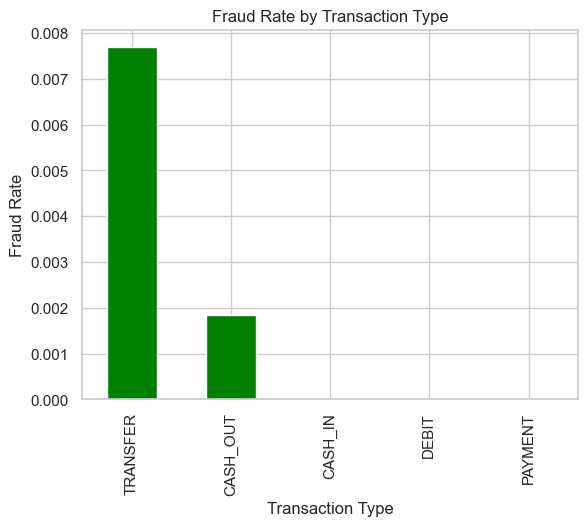

In [34]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', title="Fraud Rate by Transaction Type", color='green')
plt.xlabel("Transaction Type")  
plt.ylabel("Fraud Rate")
plt.show()


In [ ]:
fraud_by_type


type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [ ]:
# Amount Statistics & Log Histogram
df['amount'].describe()
df['amount'].describe().astype(int)


count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int32

<Axes: xlabel='amount', ylabel='Count'>

Text(0.5, 1.0, 'Log-Transformed Transaction Amount Distribution')

Text(0.5, 0, 'Log(Transaction Amount + 1)')

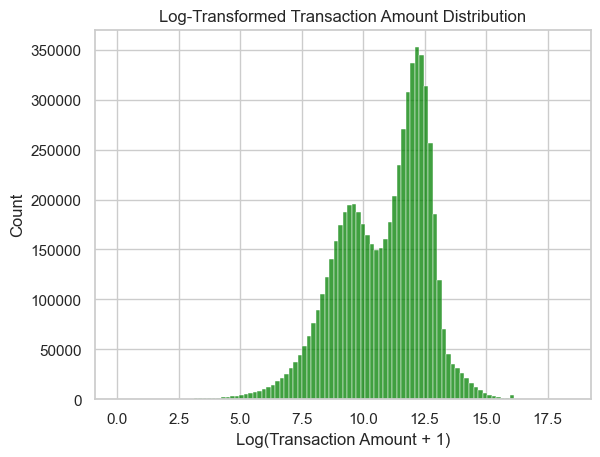

In [36]:
sns.histplot(np.log1p(df['amount']), bins=100, color='green')
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("Log(Transaction Amount + 1)")
plt.show()


<Axes: xlabel='isFraud', ylabel='amount'>

Text(0.5, 1.0, 'Boxplot of Transaction Amounts Less Than 50,000 vs Fraud Status')

Text(0.5, 0, 'Fraud Status')

Text(0, 0.5, 'Transaction Amount')

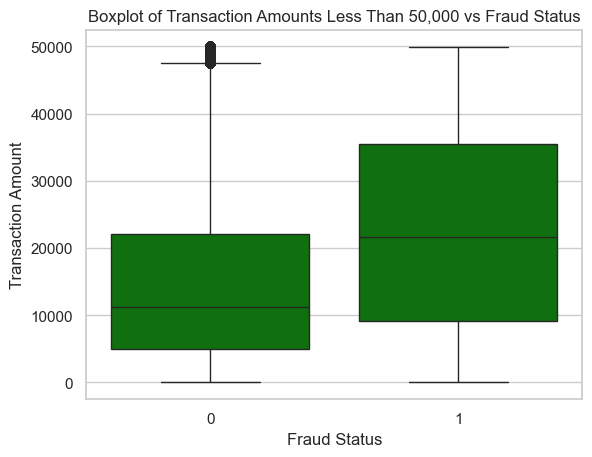

In [ ]:
# Fraud vs Amount (Boxplot)
sns.boxplot(data = df[df['amount'] < 50000], x ="isFraud",y="amount", color='green')
plt.title("Boxplot of Transaction Amounts Less Than 50,000 vs Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount")
plt.show()


In [42]:
# Balance Difference Features
# Create:
    # balance_diff_orig
    # balance_diff_dest
# Negative balance checks
# 📁 Where
    # ➡️ src/feature_engineering.py
    # ➡️ Used first in notebook, later reused in training

df["balance_diff_orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balance_diff_dest"] = df["newbalanceDest"] - df["oldbalanceDest"]


<Axes: xlabel='step'>

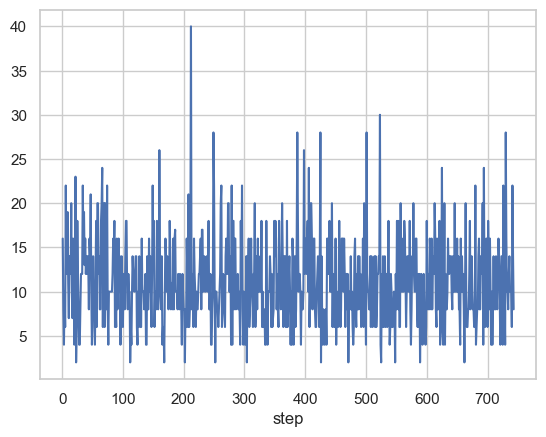

In [43]:
# Time Analysis - Fraud over time
# # Drops step feature after plotting
# 📁 Notebook

df[df["isFraud"] == 1]["step"].value_counts().sort_index().plot()
df.drop(columns=["step"], inplace=True)


In [44]:
# Top Senders / Receivers / Fraud Users
df["nameOrig"].value_counts().head(10)
df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)


nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
Name: count, dtype: int64

nameOrig
C1305486145    1
C755286039     1
C973279667     1
C258213312     1
C1640703547    1
C1127265876    1
C317779855     1
C1064034527    1
C1141104763    1
C1966863341    1
Name: count, dtype: int64

<Axes: xlabel='type', ylabel='count'>

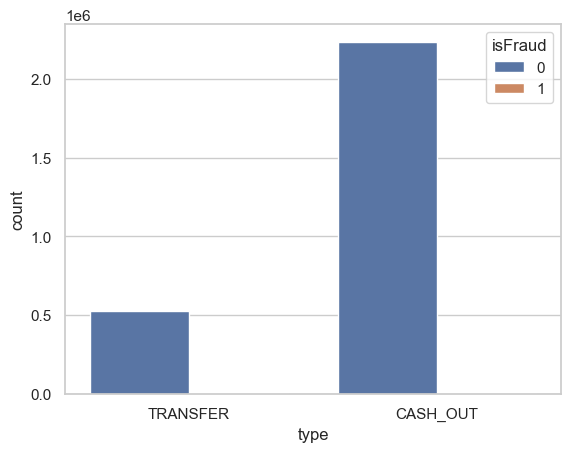

In [ ]:
# Transfer & Cash-Out Focus
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
sns.countplot(x="type", hue="isFraud", data=fraud_types)


In [46]:
# Correlation Matrix
corr = df[numeric_cols + ["isFraud"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")



NameError: name 'numeric_cols' is not defined

In [47]:
# Suspicious Zero Balance Transfers
suspicious = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]


In [ ]:
# Feature Selection & Train/Test Split
# Drop name columns

# Define X, y

# Stratified split

# 📁 main.py
X = df.drop(columns=["isFraud", "nameOrig", "nameDest", "isFlaggedFraud"])
y = df["isFraud"]


In [ ]:
# Pipeline + Class Imbalance Handling
# ColumnTransformer

# StandardScaler

# OneHotEncoder

# LogisticRegression

# class_weight='balanced'

# 📁 src/model.py


In [ ]:
# Model Evaluation 


# Classification report

# Confusion matrix

# Accuracy

# 📁 src/evaluation.py


In [ ]:
# Model Export (31:00 – 32:00)

# joblib.dump()

# 📁 models/


In [ ]:
# Streamlit App 


# Inputs

# Predict button

# Display fraud / not fraud

# Testing examples

# 📁 app/fraud_detection_app.py
